In [1]:
import tables
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2


In [2]:
a = tables.open_file("/data/cta/users-ifae/summer_students/agl/scripts/chis.h5")

In [3]:
a.root.chis2.results

/chis2/results (Table(np.int64(3505),)) np.str_('Combined chi2 results')
  description := {
  "check_index": Int32Col(shape=(), dflt=np.int32(0), pos=0),
  "chi2": Float64Col(shape=(), dflt=np.float64(0.0), pos=1),
  "dof": Int32Col(shape=(), dflt=np.int32(0), pos=2),
  "run": Int32Col(shape=(), dflt=np.int32(0), pos=3)}
  byteorder := 'little'
  chunkshape := (np.int64(3276),)

[]

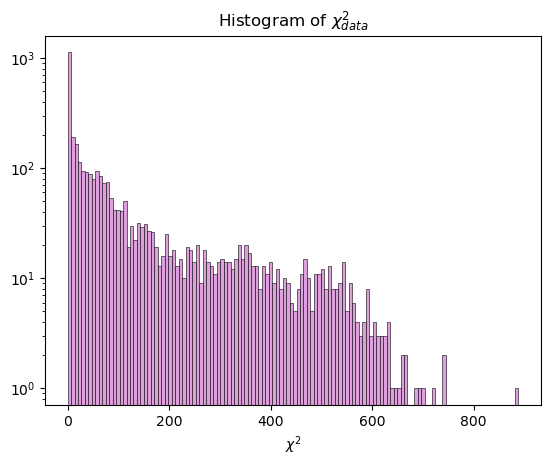

In [4]:
chi2_data = a.root.chis2.results.col('chi2')

plt.hist(chi2_data, bins=130, color='plum',  edgecolor='black', linewidth=0.4)
plt.xlabel(r'$ \chi ^2$')
plt.title(r'Histogram of $ \chi ^2_{ data}$')
plt.yscale('log')
plt.plot()



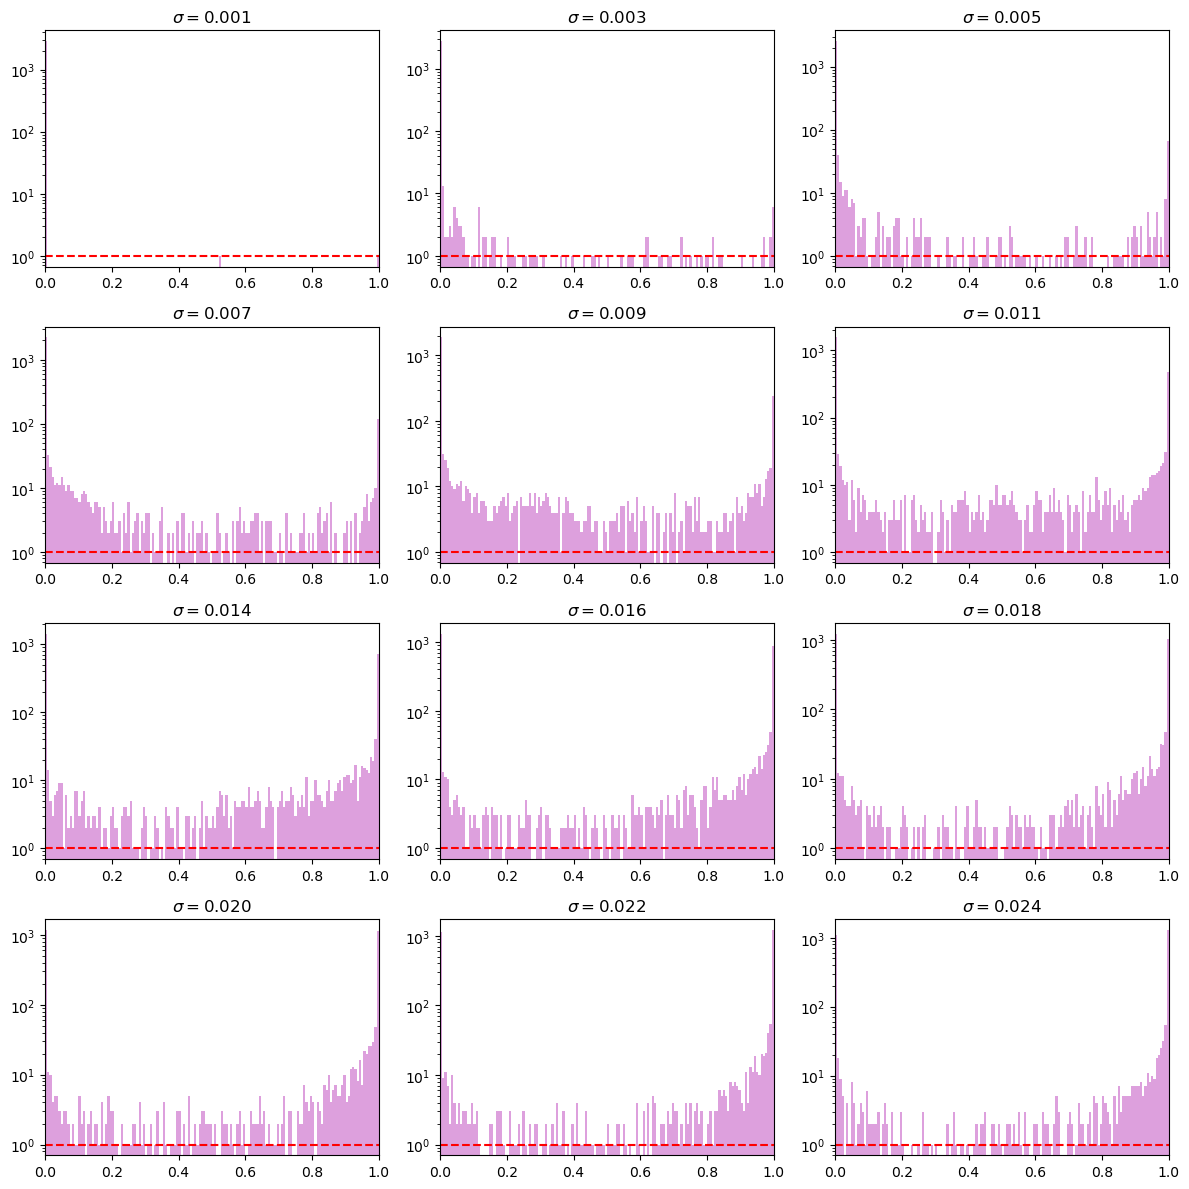

In [5]:
import math

sigma_pixels = np.linspace(0.001, 0.024, 12)

ncols = 3
nrows = math.ceil(len(sigma_pixels) / ncols)

fig, ax = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows))
ax = ax.ravel()

sigma_pixel_o = 28*np.tan(np.radians(0.05))
dof = a.root.chis2.results.col('dof')
min_dof = 2
for i, sigma in enumerate(sigma_pixels):

    chi2_data_new = (sigma_pixel_o / sigma)**2 * chi2_data
    p_values = 1 - chi2.cdf(chi2_data_new, dof)
    mask = dof > min_dof
    ax[i].hist(
        p_values[mask],
        bins=150,
        range=(0,1),
        density=False,
        color='plum',
    )

    ax[i].axhline(1, color='red', ls='--')
    ax[i].set_yscale('log')
    ax[i].set_title(rf'$\sigma={sigma:.3f}$')
    ax[i].set_xlim(0,1)

# Elimina los ejes vacíos si sobran
for j in range(len(sigma_pixels), len(ax)):
    fig.delaxes(ax[j])

plt.tight_layout()
plt.show()

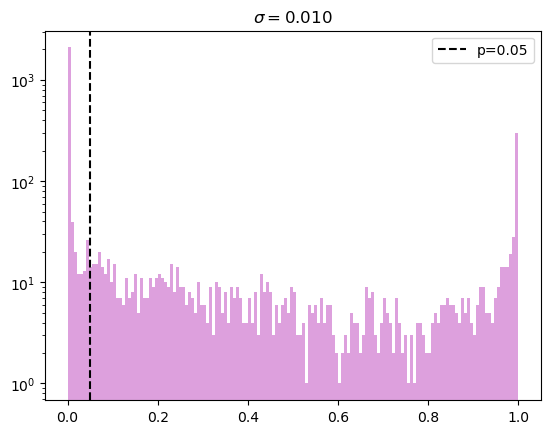

In [6]:

# Update of the sigma value
sigma_pixels = 0.01
chi2_data_new = (sigma_pixel_o / sigma_pixels)**2 * chi2_data
p_value = 1 - chi2.cdf(chi2_data_new, dof)

p_cutoff = 0.05
# Plot of the new histogram of p-value
plt.hist(p_value, bins=150, range=(0,1), density=False, color='plum')
plt.axvline(p_cutoff, linestyle ='--', color='black', label=f'p={p_cutoff}')
plt.legend()
plt.yscale('log')
plt.title(rf'$\sigma={sigma_pixels:.3f}$')
plt.show()




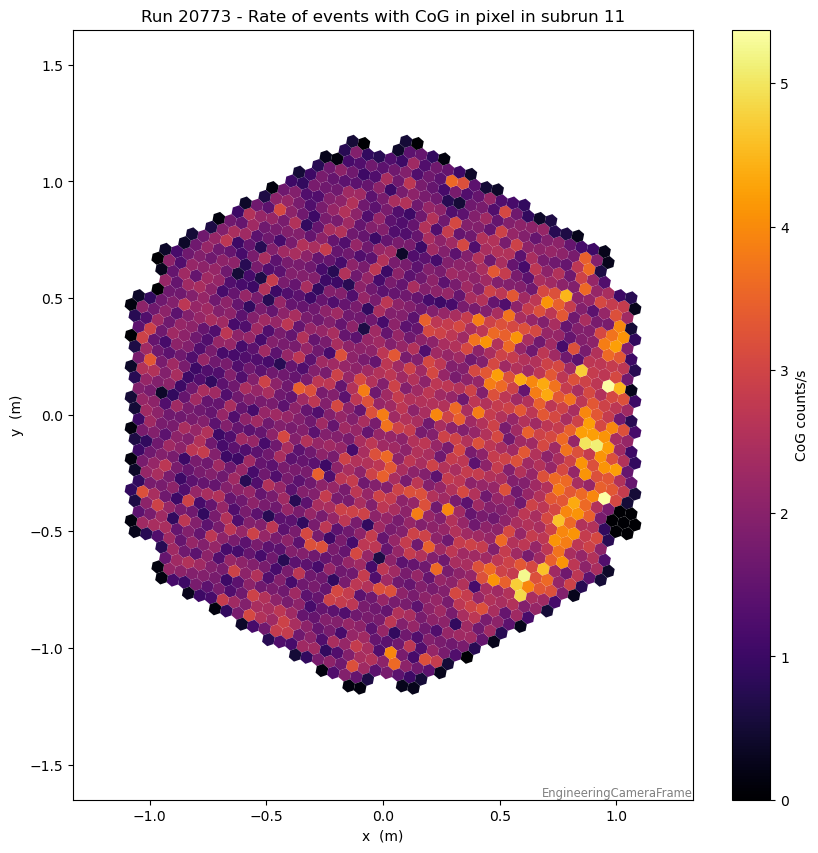

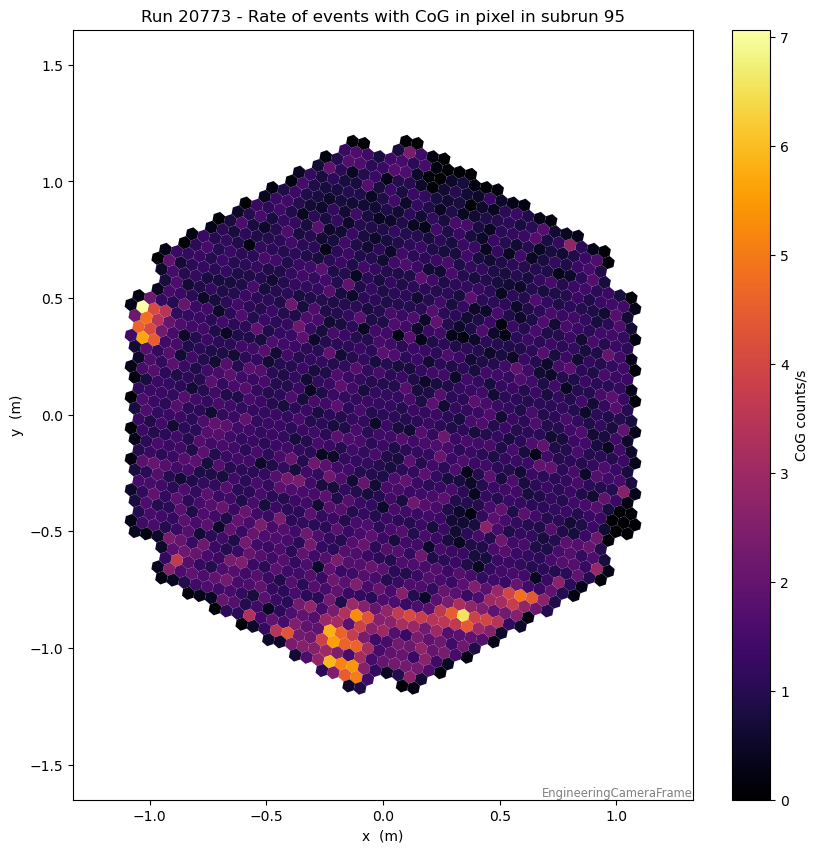

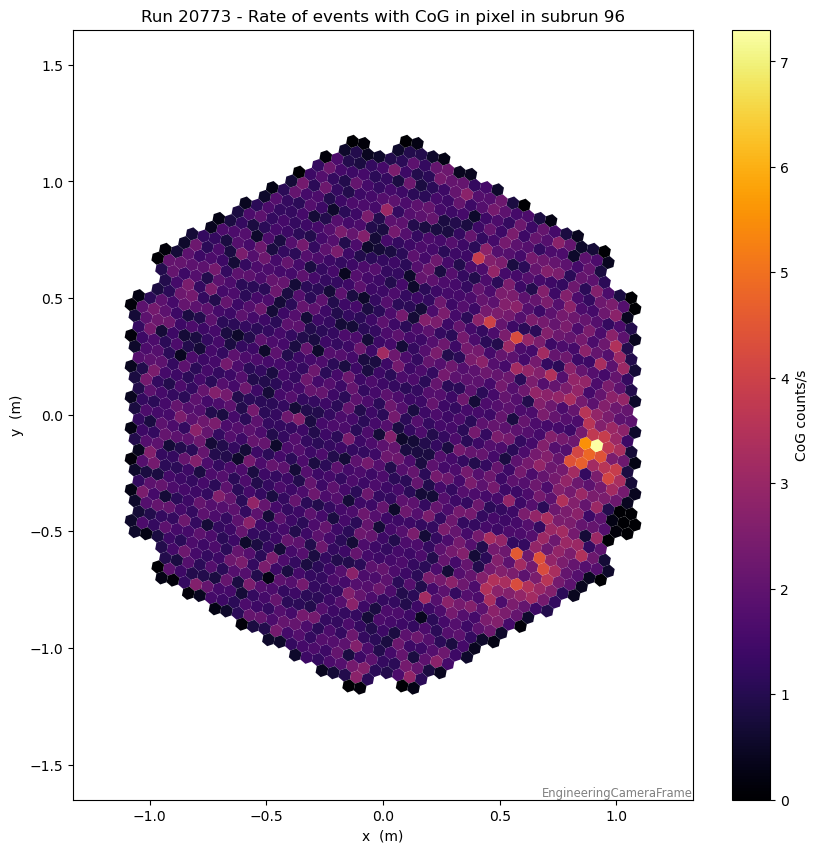

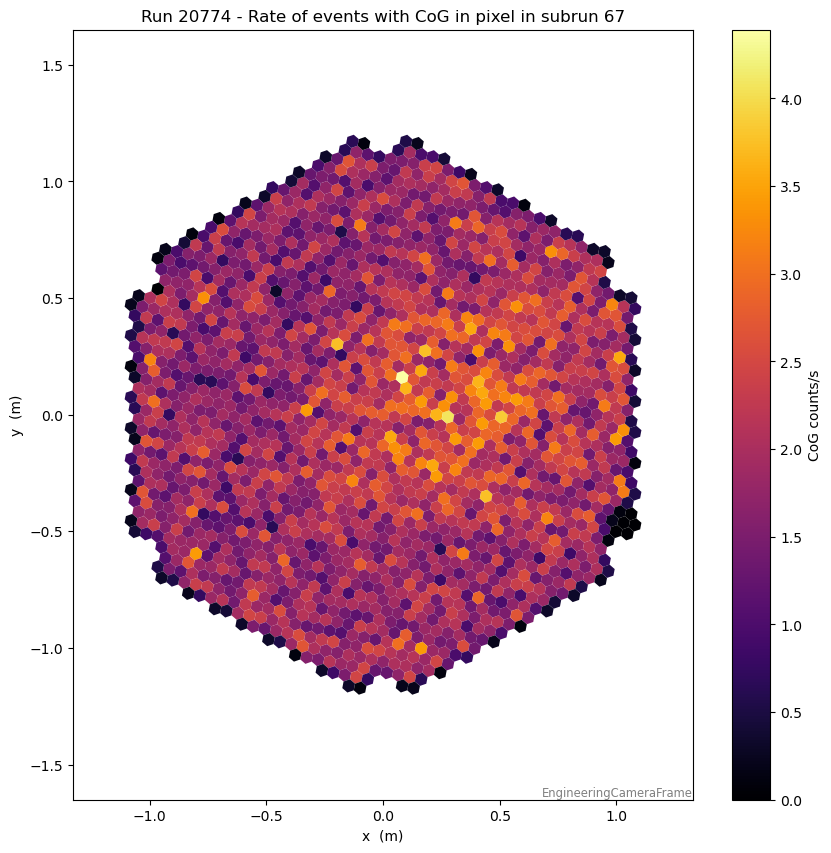

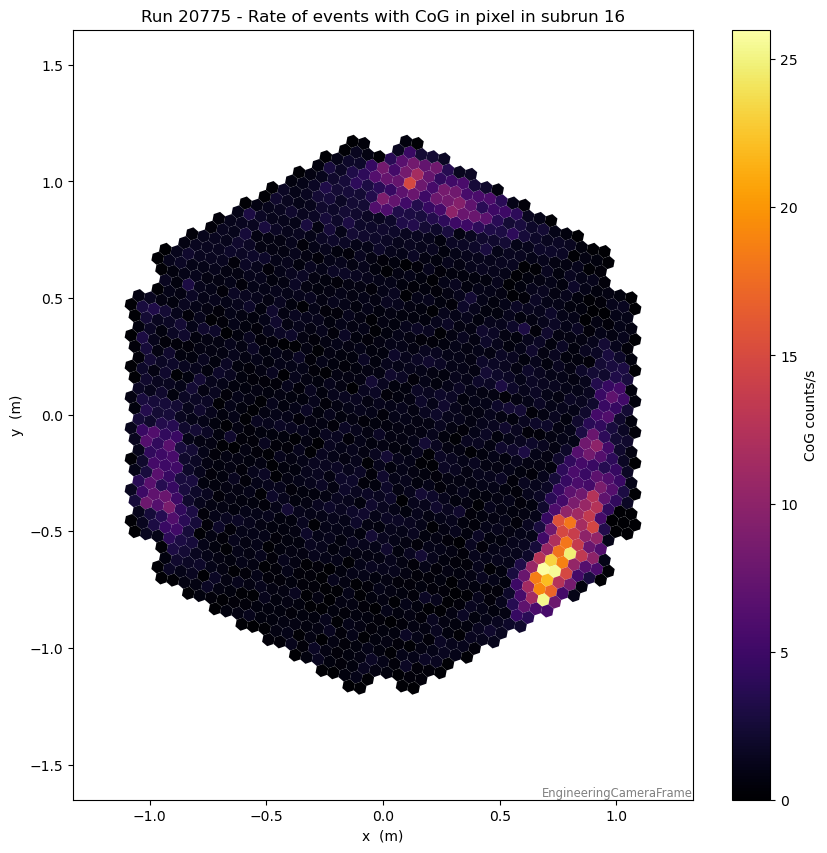

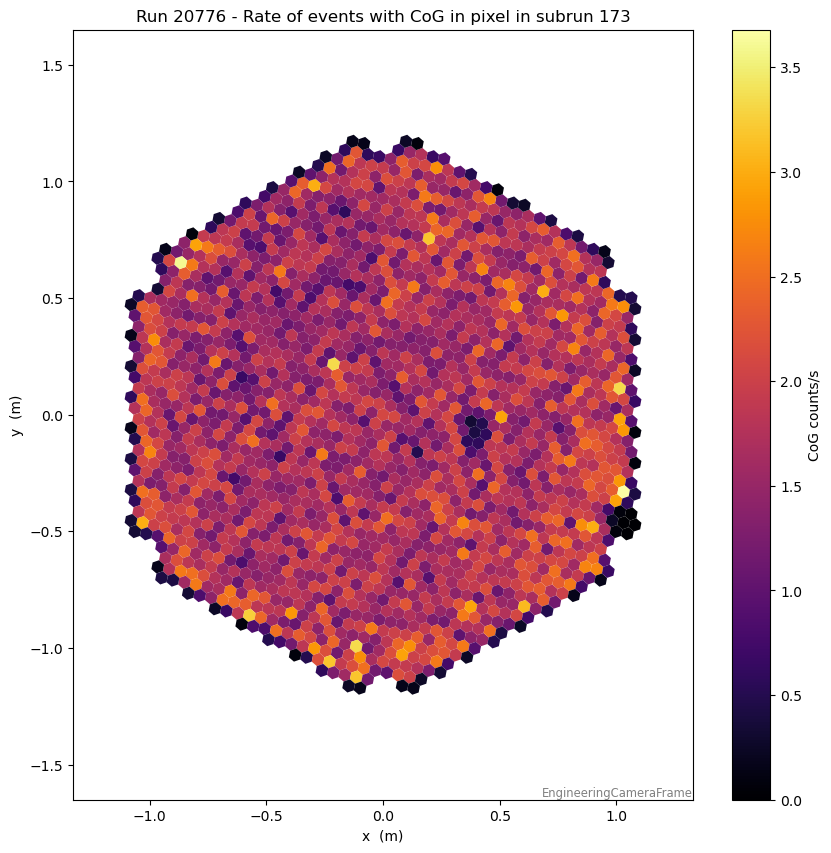

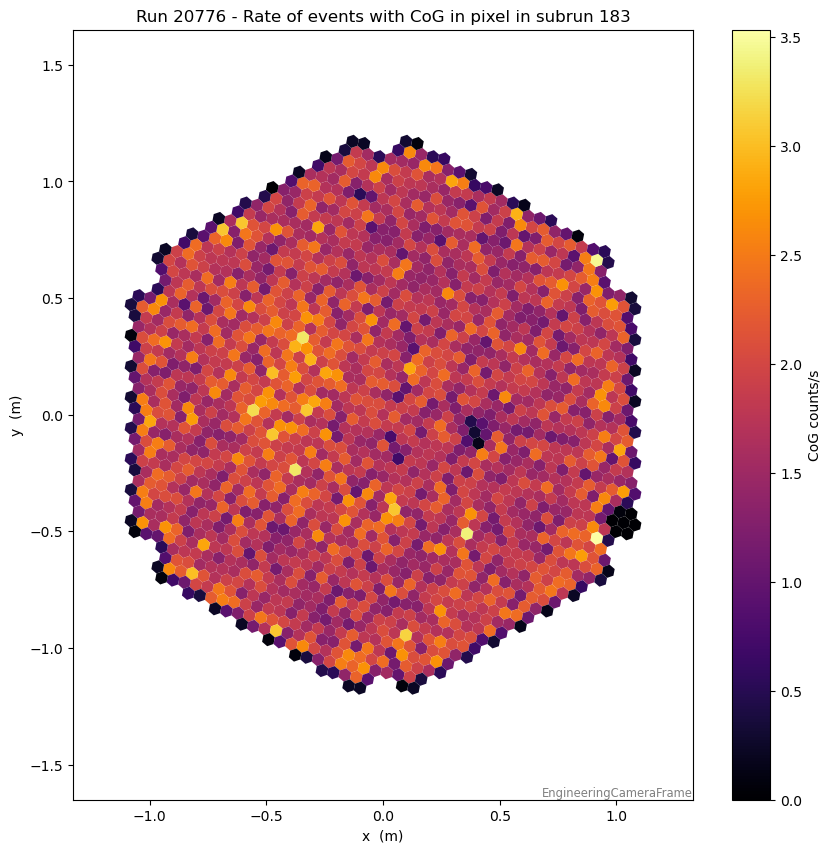

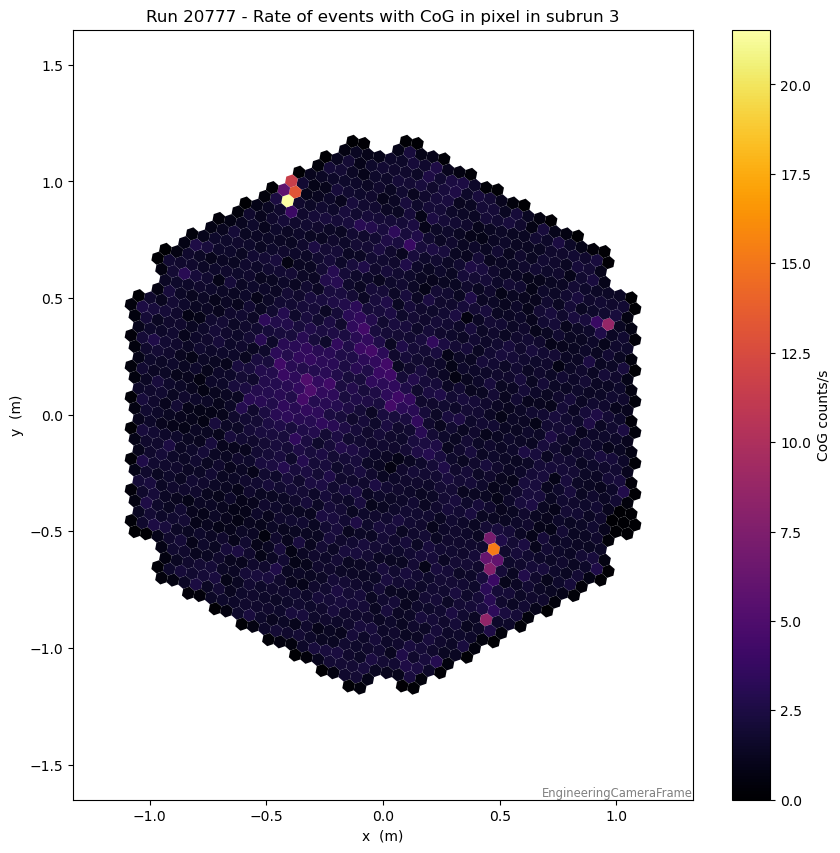

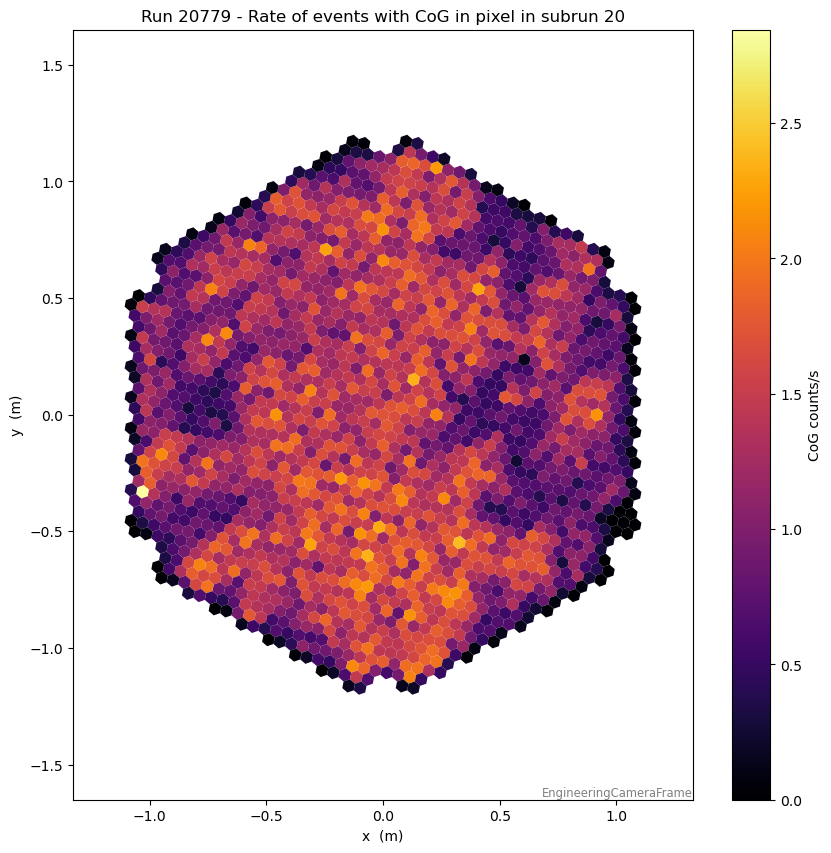

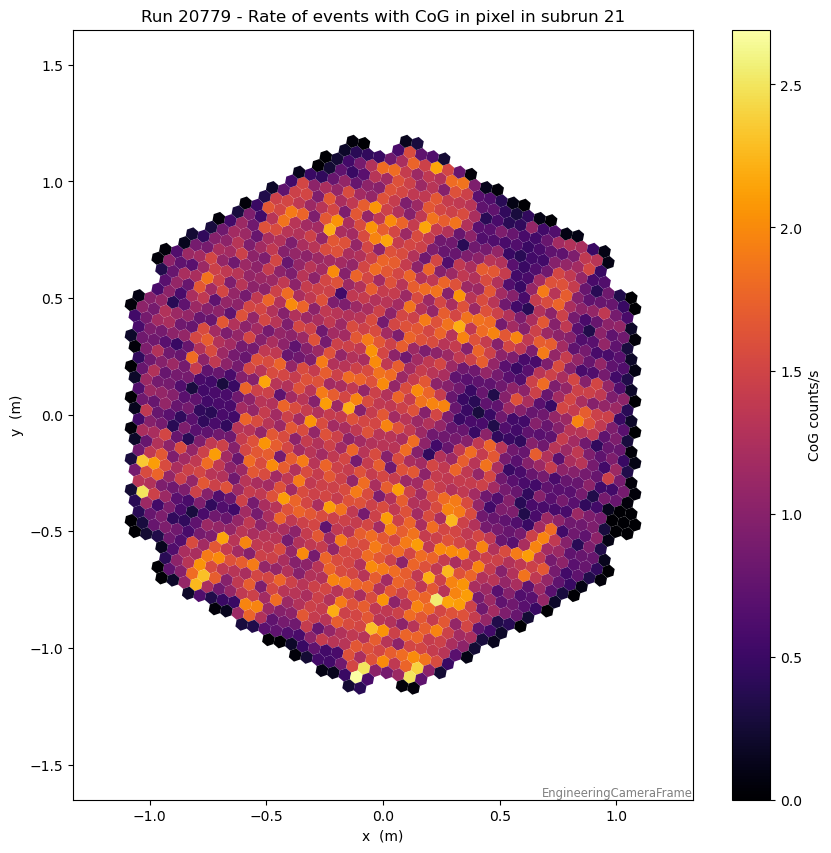

In [9]:
# See which runs are under a p-value of 0.05

from ctapipe.coordinates import EngineeringCameraFrame
from ctapipe_io_lst import LSTEventSource
from ctapipe.visualization import CameraDisplay
sa = LSTEventSource.create_subarray(tel_id=1)
focal_length = sa.tel[1].optics.equivalent_focal_length
camera_geom = sa.tel[1].camera.geometry

p_cutoff = 0.05
mask_p =  p_values < p_cutoff

runs = a.root.chis2.results.col('run')
checks = a.root.chis2.results.col('check_index')

nonlinear_runs = runs[mask_p]
nonlinear_checks = checks[mask_p]

nl_runs_list = nonlinear_runs.tolist()
nl_checks_list = nonlinear_checks.tolist()

nl_run_subrun = list(zip(nl_runs_list, nl_checks_list))

ten_pairs = nl_run_subrun[10:20]


for run_id, check in ten_pairs:
    f = tables.open_file(f"/data/cta/users-ifae/moralejo/CTA/summer_student_2026/datacheck/ALL_h5/datacheck_dl1_LST-1.Run{run_id}.h5")
    
    cog_pixel = f.root.dl1datacheck.cosmics.col('cog_within_pixel')[:-1]  # shape: (n_subruns, n_pixels)
    time = f.root.dl1datacheck.cosmics.col('elapsed_time')[:-1]
    subruns = f.root.dl1datacheck.cosmics.col('subrun_index')[:-1]
    subrun_to_row = {subrun: row for row, subrun in enumerate(subruns)}
    cog_rate = cog_pixel / time[:, None]
    
    anomalous_row = subrun_to_row[check]
    
    # Plot of CoG rate within pixel for anomalous subrun
    plt.figure(figsize=(10, 10))
    camdisplay = CameraDisplay(
        camera_geom.transform_to(EngineeringCameraFrame()),
        norm='lin',
        title=f'Run {run_id} - Rate of events with CoG in pixel in subrun {check}',
        image=cog_rate[anomalous_row, :],
    )
    camdisplay.autoupdate = True
    camdisplay.add_colorbar(label='CoG counts/s')
    plt.show()
  


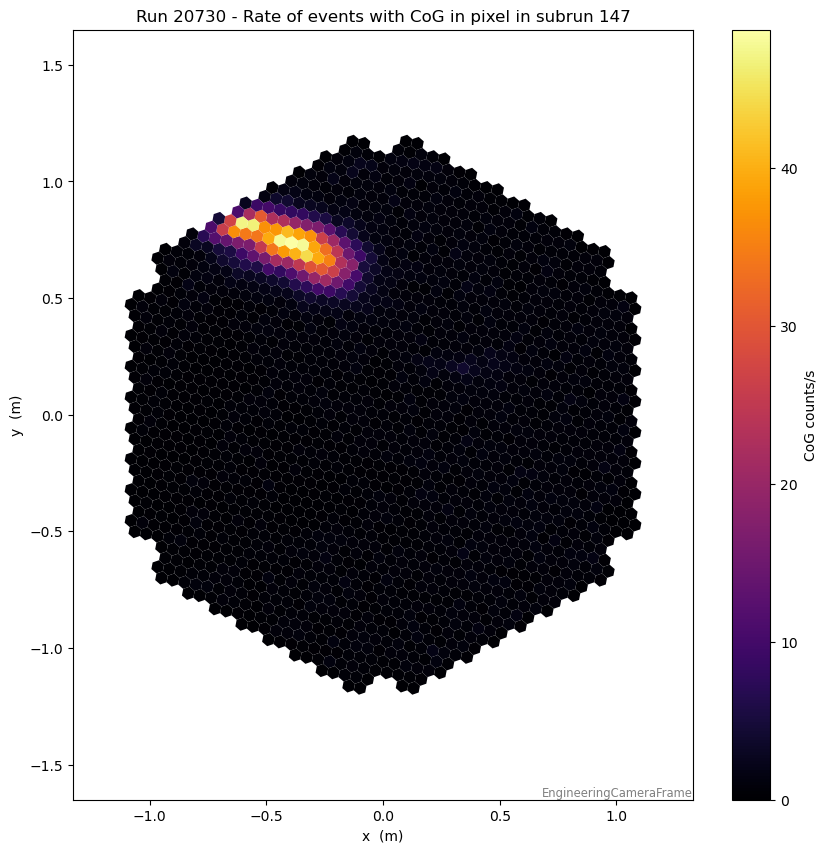

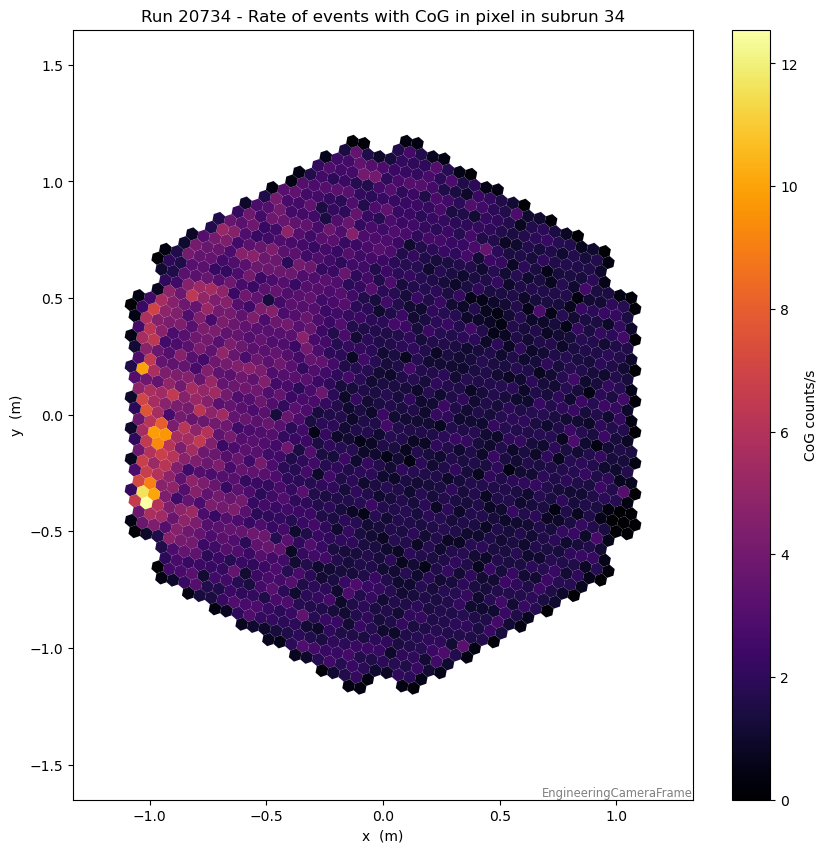

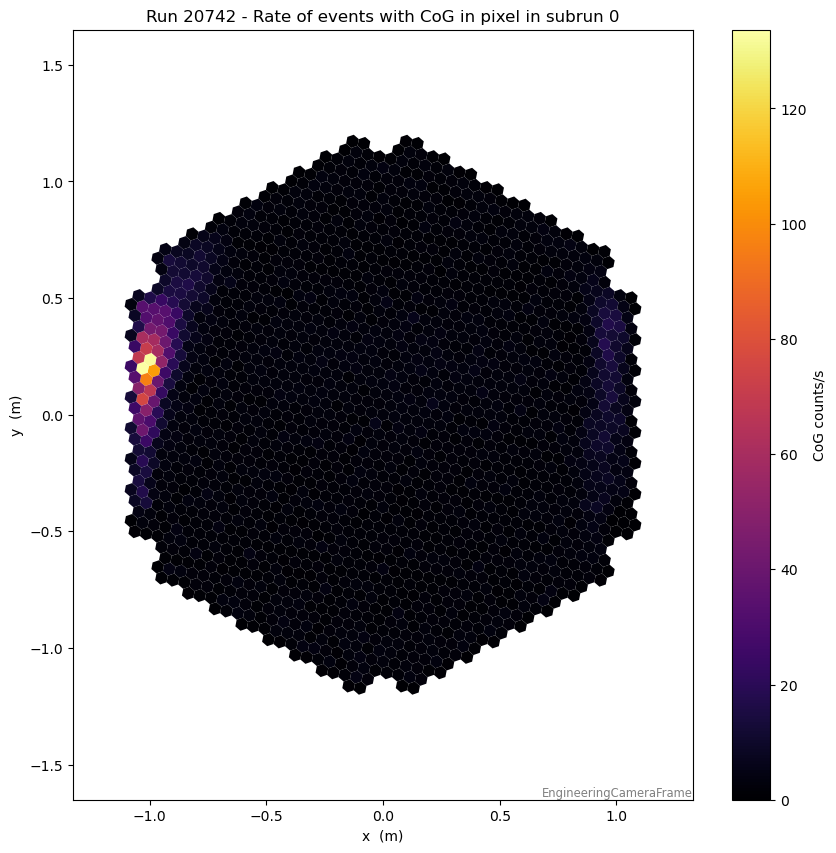

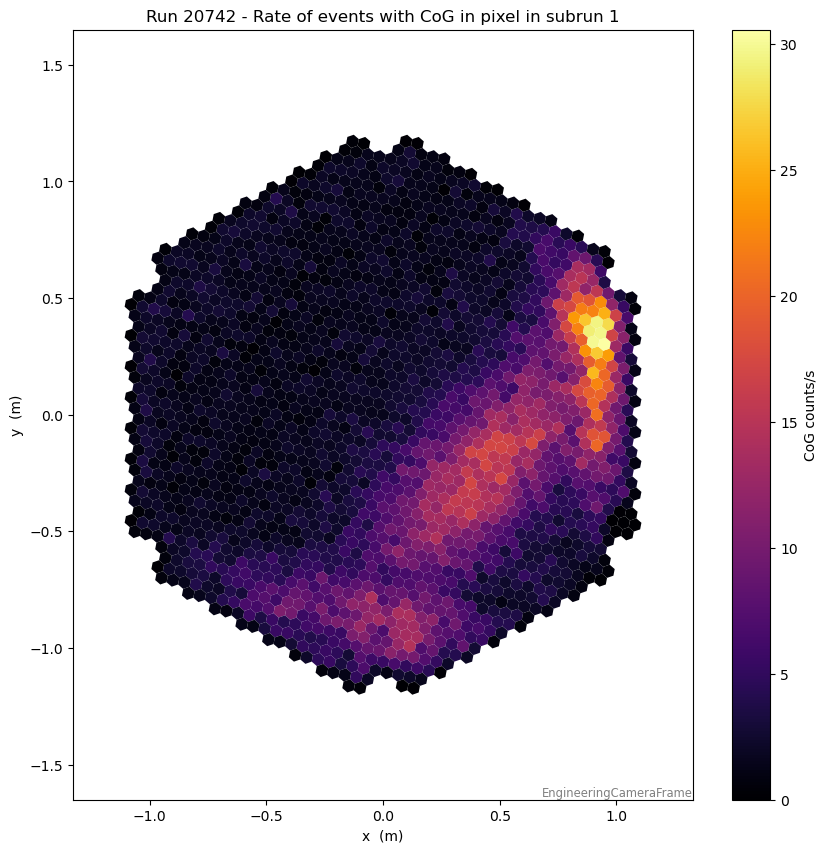

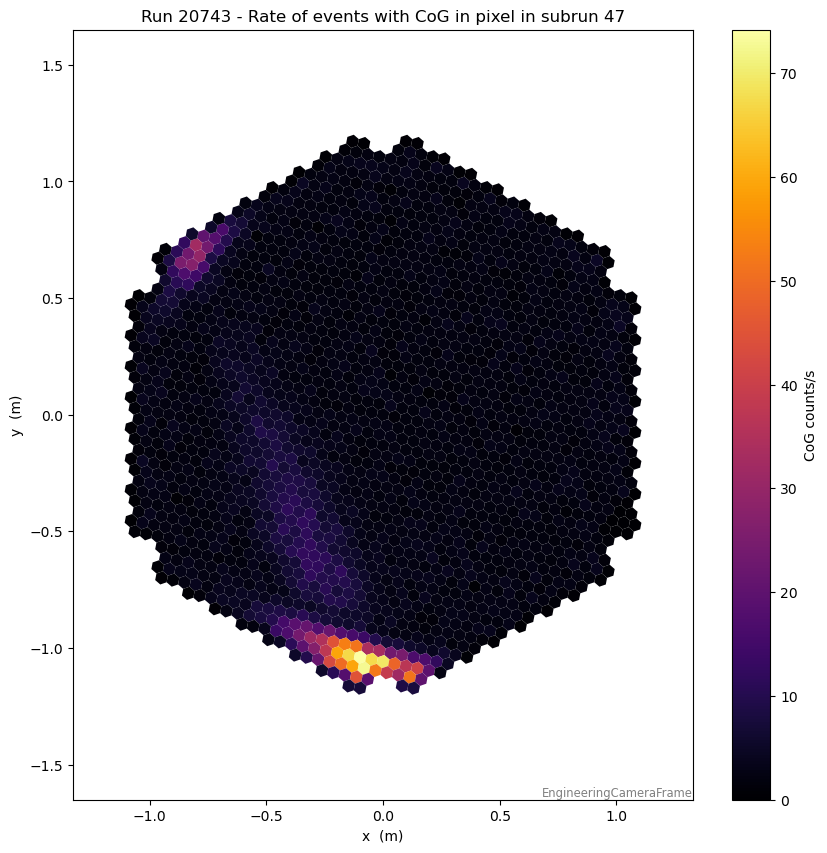

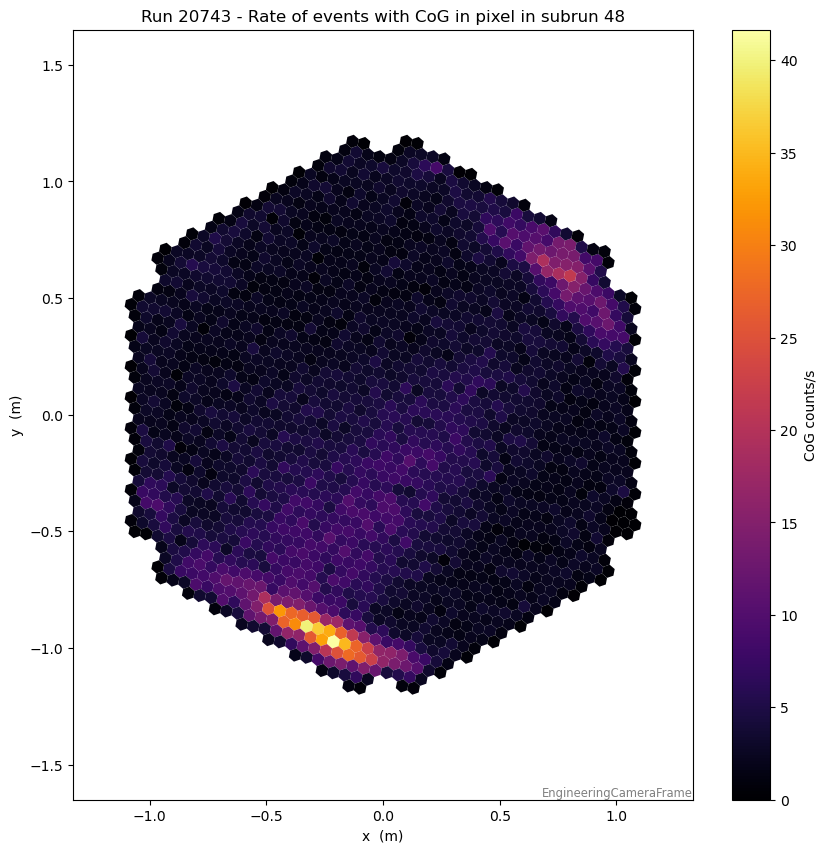

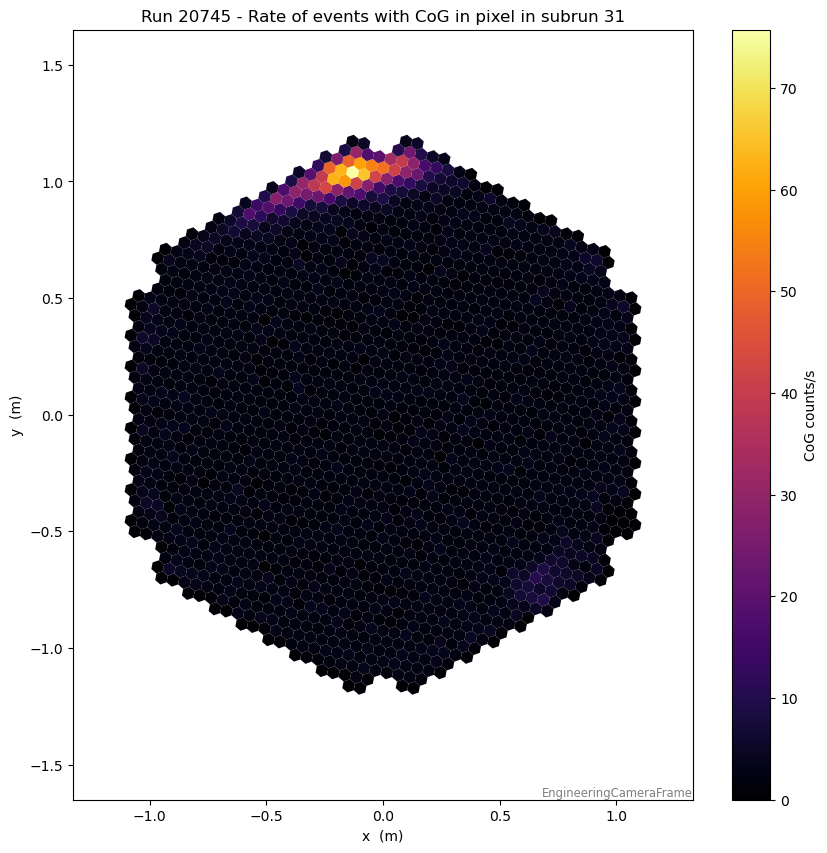

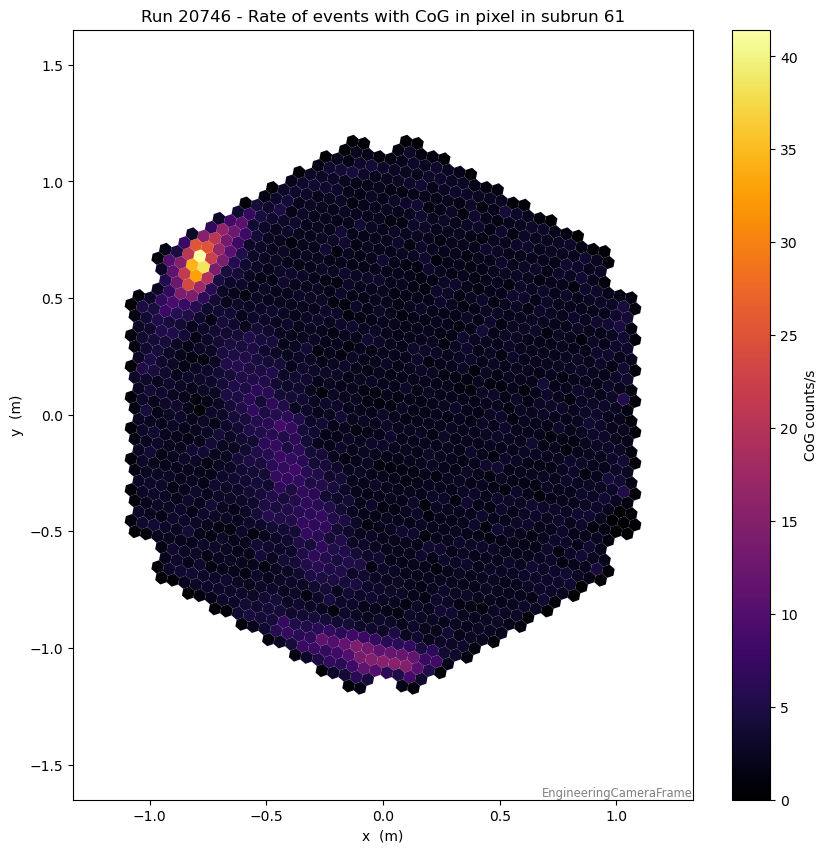

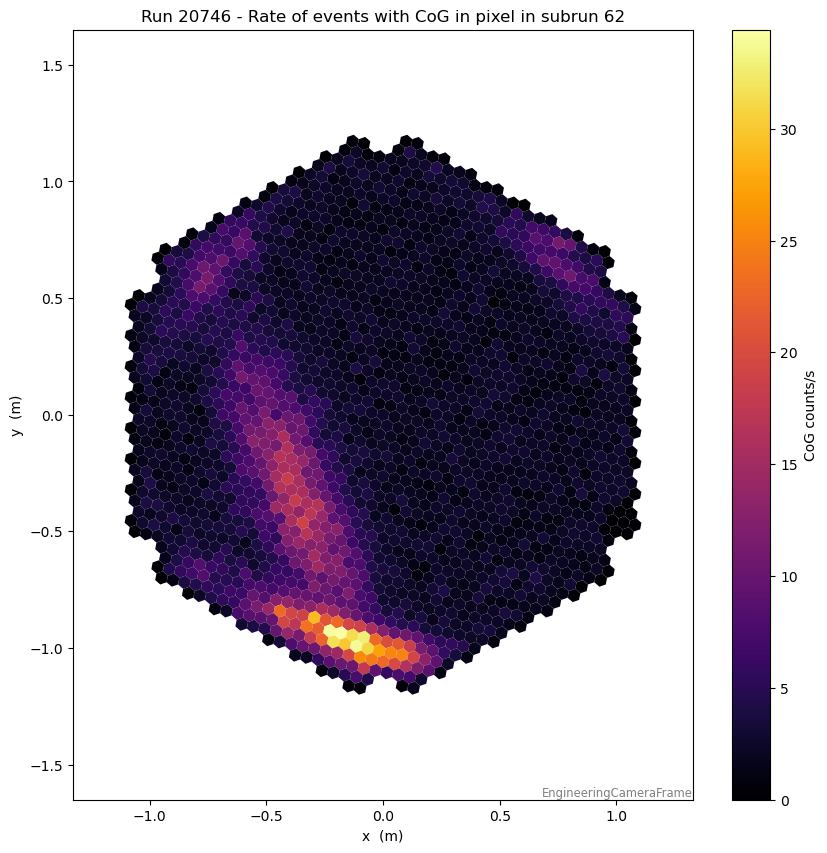

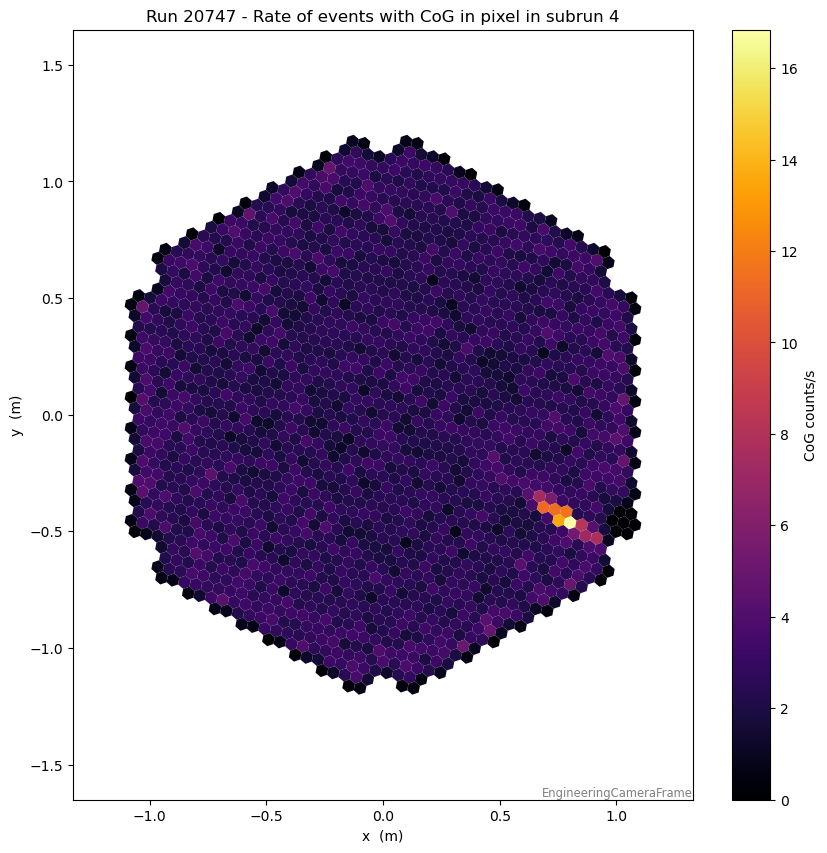

In [10]:
# See which runs are over a p-value of 0.95
p_cutoff = 0.99
mask_p =  p_values > p_cutoff

runs = a.root.chis2.results.col('run')
checks = a.root.chis2.results.col('check_index')

nonlinear_runs = runs[mask_p]
nonlinear_checks = checks[mask_p]

nl_runs_list = nonlinear_runs.tolist()
nl_checks_list = nonlinear_checks.tolist()

nl_run_subrun = list(zip(nl_runs_list, nl_checks_list))

ten_pairs = nl_run_subrun[10:20]


for run_id, check in ten_pairs:
    f = tables.open_file(f"/data/cta/users-ifae/moralejo/CTA/summer_student_2026/datacheck/ALL_h5/datacheck_dl1_LST-1.Run{run_id}.h5")
    
    cog_pixel = f.root.dl1datacheck.cosmics.col('cog_within_pixel')[:-1]  # shape: (n_subruns, n_pixels)
    time = f.root.dl1datacheck.cosmics.col('elapsed_time')[:-1]
    subruns = f.root.dl1datacheck.cosmics.col('subrun_index')[:-1]
    subrun_to_row = {subrun: row for row, subrun in enumerate(subruns)}
    cog_rate = cog_pixel / time[:, None]
    
    anomalous_row = subrun_to_row[check]
    
    # Plot of CoG rate within pixel for anomalous subrun
    plt.figure(figsize=(10, 10))
    camdisplay = CameraDisplay(
        camera_geom.transform_to(EngineeringCameraFrame()),
        norm='lin',
        title=f'Run {run_id} - Rate of events with CoG in pixel in subrun {check}',
        image=cog_rate[anomalous_row, :],
    )
    camdisplay.autoupdate = True
    camdisplay.add_colorbar(label='CoG counts/s')
    plt.show()
    f.close()
    

